# SEMANA 5: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO

### Integrante:
### Anccasi Pozo Joseph

### 1.	Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository  y utilizando las librerías de Python que se indican, haga lo siguiente:

### a.	Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.

In [18]:
import pandas as pd
import numpy as np
# Nombres de columnas según el repositorio
columnas = [
    'ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape',
    'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei',
    'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class'
]

# Leer el archivo desde la URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
df = pd.read_csv(url, names=columnas)
df

,ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [59]:
# Reemplazar '?' por NaN
df.replace('?', np.nan, inplace=True)

# Convertir Bare_Nuclei a numérico
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'])

# Eliminar filas con valores NaN 
df.dropna(inplace=True)

# Ver cuántos NaN hay en cada columna
print(df.isnull().sum())

ID                             0
Clump_Thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


In [30]:
# Separar columnas numéricas
numericas = df.select_dtypes(include=[np.number])

# Separar columnas no numéricas (por ejemplo, 'ID' puede considerarse no relevante para análisis)
no_numericas = df.select_dtypes(exclude=[np.number])

# Estadísticas descriptivas
estadisticas = numericas.describe()
print(estadisticas)


                 ID  Clump_Thickness  Uniformity_Cell_Size  \
count  6.830000e+02       683.000000            683.000000   
mean   1.076720e+06         4.442167              3.150805   
std    6.206440e+05         2.820761              3.065145   
min    6.337500e+04         1.000000              1.000000   
25%    8.776170e+05         2.000000              1.000000   
50%    1.171795e+06         4.000000              1.000000   
75%    1.238705e+06         6.000000              5.000000   
max    1.345435e+07        10.000000             10.000000   

       Uniformity_Cell_Shape  Marginal_Adhesion  Single_Epithelial_Cell_Size  \
count             683.000000         683.000000                   683.000000   
mean                3.215227           2.830161                     3.234261   
std                 2.988581           2.864562                     2.223085   
min                 1.000000           1.000000                     1.000000   
25%                 1.000000           1.

In [32]:
# Matriz de correlación
correlacion = numericas.corr()
print(correlacion)


                                   ID  Clump_Thickness  Uniformity_Cell_Size  \
ID                           1.000000        -0.056350             -0.041396   
Clump_Thickness             -0.056350         1.000000              0.642481   
Uniformity_Cell_Size        -0.041396         0.642481              1.000000   
Uniformity_Cell_Shape       -0.042221         0.653470              0.907228   
Marginal_Adhesion           -0.069630         0.487829              0.706977   
Single_Epithelial_Cell_Size -0.048644         0.523596              0.753544   
Bare_Nuclei                 -0.099248         0.593091              0.691709   
Bland_Chromatin             -0.061966         0.553742              0.755559   
Normal_Nucleoli             -0.050699         0.534066              0.719346   
Mitoses                     -0.037972         0.350957              0.460755   
Class                       -0.084701         0.714790              0.820801   

                             Uniformity

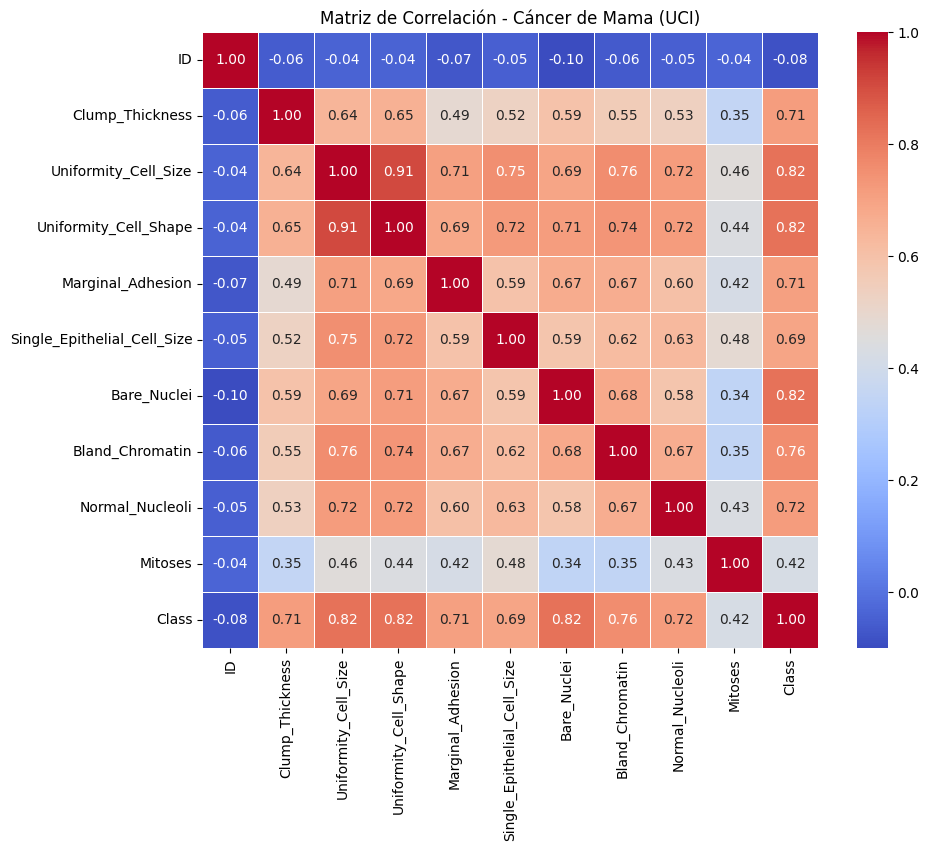

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))  # Tamaño del gráfico
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Cáncer de Mama (UCI)')
plt.show()


#### Tras limpiar y separar los datos, calculamos los estadísticos descriptivos de las variables numéricas y analizamos la matriz de correlación. La visualización con el mapa de calor mostró que algunas variables, como el tamaño y la forma celular, están fuertemente correlacionadas, lo que sugiere que tienen una relación significativa en la clasificación del cáncer de mama. Observando la matriz de correlación, destacamos que variables como Uniformity_Cell_Size y Uniformity_Cell_Shape tienen correlaciones muy altas entre sí (0.91) y con la variable Class (0.82 y 0.82 respectivamente), lo que indica que son factores importantes en la clasificación de los tumores. De igual manera, Bare_Nuclei muestra una fuerte correlación con Class (0.82), lo que refuerza su relevancia en la predicción del tipo de tumor. En general, estos análisis nos ofrecen una base sólida para futuros modelos predictivos y un entendimiento claro de cómo las características del cáncer de mama están interrelacionadas.

### b.	Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.


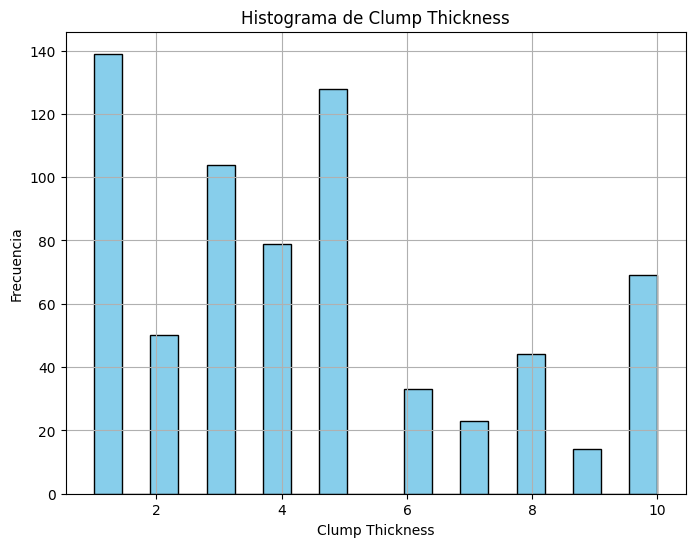

In [38]:
import matplotlib.pyplot as plt

# Histograma de la columna 'Clump_Thickness'
plt.figure(figsize=(8, 6))
plt.hist(df['Clump_Thickness'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de Clump Thickness')
plt.xlabel('Clump Thickness')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


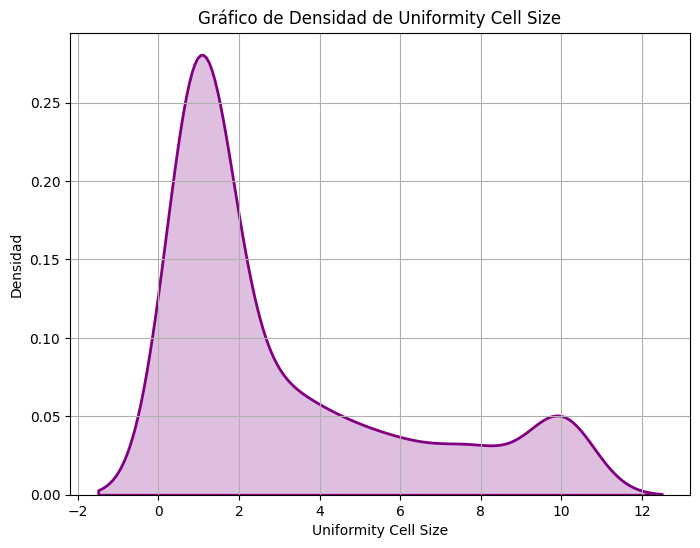

In [40]:
import seaborn as sns

# Gráfico de densidad para la variable 'Uniformity_Cell_Size'
plt.figure(figsize=(8, 6))
sns.kdeplot(df['Uniformity_Cell_Size'], fill=True, color='purple', linewidth=2)
plt.title('Gráfico de Densidad de Uniformity Cell Size')
plt.xlabel('Uniformity Cell Size')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()


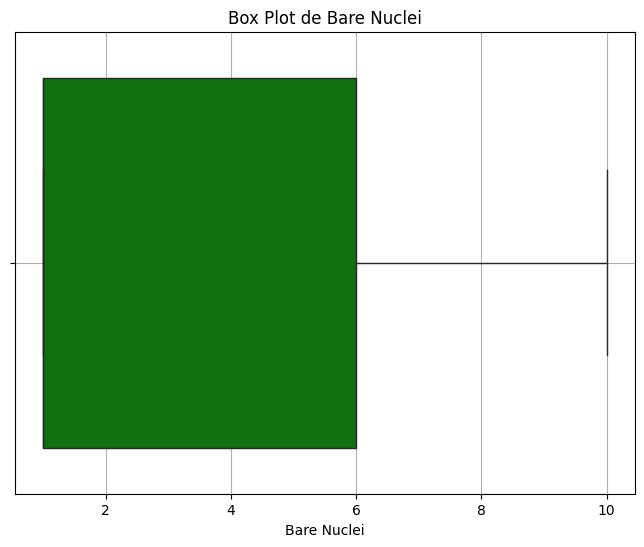

In [42]:
# Box plot para la variable 'Bare_Nuclei'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Bare_Nuclei'], color='green')
plt.title('Box Plot de Bare Nuclei')
plt.xlabel('Bare Nuclei')
plt.grid(True)
plt.show()


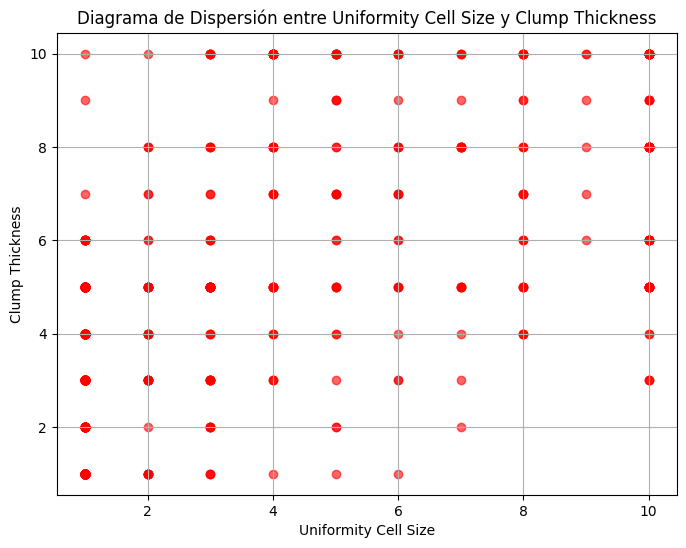

In [44]:
# Diagrama de dispersión entre 'Uniformity_Cell_Size' y 'Clump_Thickness'
plt.figure(figsize=(8, 6))
plt.scatter(df['Uniformity_Cell_Size'], df['Clump_Thickness'], color='red', alpha=0.6)
plt.title('Diagrama de Dispersión entre Uniformity Cell Size y Clump Thickness')
plt.xlabel('Uniformity Cell Size')
plt.ylabel('Clump Thickness')
plt.grid(True)
plt.show()


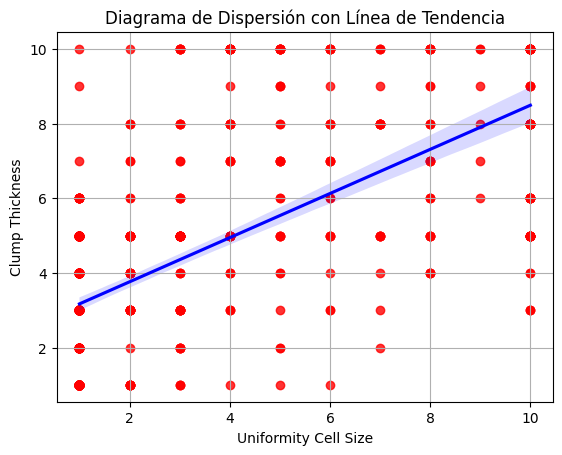

In [46]:
# Agregar línea de tendencia (regresión lineal)
sns.regplot(x='Uniformity_Cell_Size', y='Clump_Thickness', data=df, scatter_kws={'color': 'red'}, line_kws={'color': 'blue'})
plt.title('Diagrama de Dispersión con Línea de Tendencia')
plt.xlabel('Uniformity Cell Size')
plt.ylabel('Clump Thickness')
plt.grid(True)
plt.show()


#### Los gráficos realizados nos permitieron explorar visualmente la distribución y relación entre las variables más relevantes del conjunto de datos. El histograma y el gráfico de densidad mostraron que variables como Clump_Thickness y Uniformity_Cell_Size presentan distribuciones sesgadas hacia valores más altos, lo cual puede estar relacionado con tumores malignos. El box plot de Bare_Nuclei reveló la presencia de varios valores atípicos, lo que sugiere una gran variabilidad en esa característica. Por otro lado, el diagrama de dispersión entre Uniformity_Cell_Size y Clump_Thickness evidenció una correlación positiva, reforzada por la línea de tendencia, lo que indica que a medida que una variable aumenta, la otra también tiende a hacerlo. Estos hallazgos respaldan la importancia de estas variables en la clasificación del cáncer de mama.

### c.	Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba. Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Separar variables (X) y etiqueta (y)
X = df.drop(['ID', 'Class'], axis=1)  # Eliminamos ID y la etiqueta
y = df['Class']


In [51]:
# Separar datos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [53]:
# Crear el modelo con k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [55]:
# Predicciones para entrenamiento y prueba
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calcular precisión
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f'Precisión en entrenamiento: {train_accuracy:.2f}')
print(f'Precisión en prueba: {test_accuracy:.2f}')


Precisión en entrenamiento: 0.97
Precisión en prueba: 0.96


In [57]:
print("Reporte en datos de prueba:")
print(classification_report(y_test, y_test_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_test_pred))


Reporte en datos de prueba:
              precision    recall  f1-score   support

           2       0.95      0.98      0.97       127
           4       0.97      0.92      0.95        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.96       205
weighted avg       0.96      0.96      0.96       205

Matriz de confusión:
[[125   2]
 [  6  72]]


#### Se realizó un análisis predictivo utilizando el conjunto de datos de cáncer de mama del repositorio UCI, en el cual se aplicó un modelo de clasificación k-NN (k-Nearest Neighbors) para distinguir entre tumores benignos y malignos. Tras limpiar y preparar los datos con la librería Pandas, se separaron en conjuntos de entrenamiento y prueba, logrando una precisión del 97% en entrenamiento y del 96% en prueba, lo que indica una buena capacidad de generalización del modelo. El reporte de clasificación y la matriz de confusión mostraron un buen balance entre precisión y sensibilidad, especialmente destacando una alta capacidad para identificar correctamente los casos malignos (recall del 92%), lo cual es crucial en contextos médicos. En resumen, el modelo k-NN demostró ser una herramienta eficaz y confiable para este tipo de diagnóstico basado en datos.